In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print('libraries loaded!')

libraries loaded!


In [7]:
df = pd.read_csv('customer_reviews_raw.csv')
print('shape:', df.shape)
df.head()

shape: (1000, 4)


,Review_ID,Product_ID,Review_Text,Star_Rating
0,1,PROD_370,This product is absolutely amazing! Loved e...,3
1,2,PROD_714,<b>Worst purchase ever</b> do not buy this gar...,2
2,3,PROD_558,<br><p>Excellent product</p> highly recommende...,5
3,4,PROD_230,Waste of money!! stopped working after one week,5
4,5,PROD_591,"Not bad not great, somewhere in the middle i t...",2


In [8]:
print('raw reviews before cleaning:')
for i in range(5):
    print(f'{i+1}.', repr(df['Review_Text'][i]))

raw reviews before cleaning:
1. '   This product is absolutely amazing! Loved every bit of it 😍   '
2. '<b>Worst purchase ever</b> do not buy this garbage<p>'
3. '<br><p>Excellent product</p> highly recommended to everyone<br>'
4. 'Waste of money!! stopped working after one week  '
5. 'Not bad not great, somewhere in the middle i think'


In [9]:
def clean_text(text):
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'&[a-z]+;', '', text)
    text = re.sub(r'[^\x00-\x7F]+', '', text)
    text = re.sub(r'\s+', ' ', text)
    text = text.strip().lower()
    return text

df['Cleaned_Review'] = df['Review_Text'].apply(clean_text)

print('after cleaning:')
for i in range(5):
    print(f'{i+1}.', df['Cleaned_Review'][i])

after cleaning:
1. this product is absolutely amazing! loved every bit of it
2. worst purchase ever do not buy this garbage
3. excellent product highly recommended to everyone
4. waste of money!! stopped working after one week
5. not bad not great, somewhere in the middle i think


In [10]:
from transformers import pipeline

sentiment_pipeline = pipeline(
    'sentiment-analysis',
    model='distilbert-base-uncased-finetuned-sst-2-english',
    device=-1
)

print('model loaded!')
test = sentiment_pipeline('this product is absolutely amazing!')
print('test output:', test)

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

model loaded!
test output: [{'label': 'POSITIVE', 'score': 0.9998841285705566}]


In [11]:
results = sentiment_pipeline(
    df['Cleaned_Review'].tolist(),
    batch_size=32,
    truncation=True,
    max_length=512
)

df['Predicted_Sentiment'] = [r['label'] for r in results]
df['Confidence_Score']    = [round(r['score'], 4) for r in results]

print('inference done!')
df[['Cleaned_Review', 'Predicted_Sentiment', 'Confidence_Score']].head(10)

inference done!


,Cleaned_Review,Predicted_Sentiment,Confidence_Score
0,this product is absolutely amazing! loved ever...,POSITIVE,0.9999
1,worst purchase ever do not buy this garbage,NEGATIVE,0.9995
2,excellent product highly recommended to everyone,POSITIVE,0.9998
3,waste of money!! stopped working after one week,NEGATIVE,0.9998
4,"not bad not great, somewhere in the middle i t...",NEGATIVE,0.9925
5,super fast delivery and product quality is top...,POSITIVE,0.9998
6,"complete scam, returned it immediately. 0 stars",NEGATIVE,0.7960
7,amazing value for money. really impressed with...,POSITIVE,0.9999
8,best product in this price range hands down,NEGATIVE,0.6948
9,packaging was great and product works flawlessly,POSITIVE,0.9999


In [12]:
print('sentiment distribution:')
print(df['Predicted_Sentiment'].value_counts())
print()
print('avg confidence:', round(df['Confidence_Score'].mean(), 4))

sentiment distribution:
Predicted_Sentiment
POSITIVE    530
NEGATIVE    470
Name: count, dtype: int64

avg confidence: 0.9798


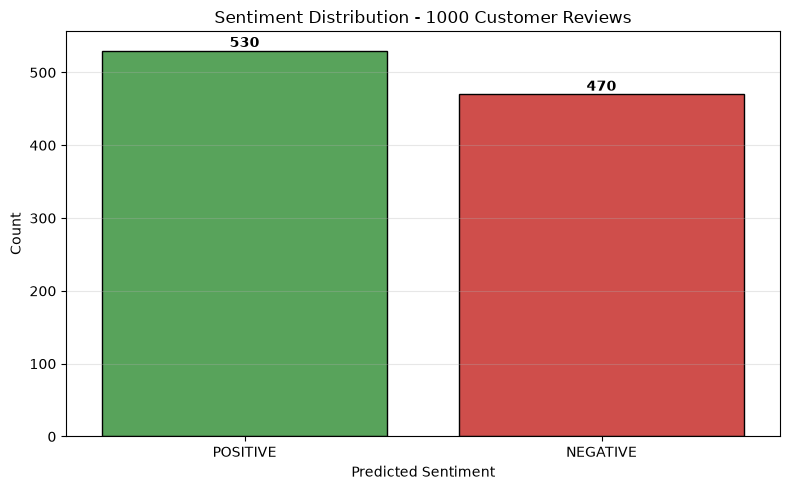

In [13]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=df,
    x='Predicted_Sentiment',
    hue='Predicted_Sentiment',
    order=['POSITIVE', 'NEGATIVE'],
    palette={'POSITIVE': '#4CAF50', 'NEGATIVE': '#E53935'},
    edgecolor='black',
    legend=False
)
plt.title('Sentiment Distribution - 1000 Customer Reviews')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Count')
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 5,
            str(int(p.get_height())), ha='center', fontweight='bold')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

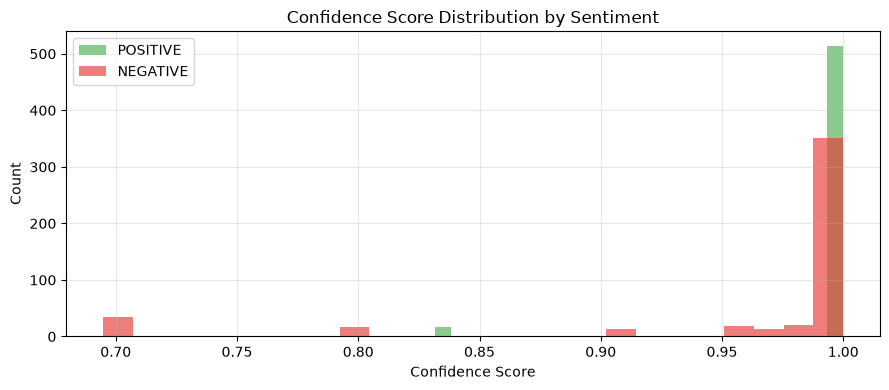

In [14]:
plt.figure(figsize=(9, 4))
for label, color in [('POSITIVE', '#4CAF50'), ('NEGATIVE', '#E53935')]:
    subset = df[df['Predicted_Sentiment'] == label]['Confidence_Score']
    plt.hist(subset, bins=25, alpha=0.65, color=color, label=label, edgecolor='none')
plt.title('Confidence Score Distribution by Sentiment')
plt.xlabel('Confidence Score')
plt.ylabel('Count')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('confidence_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
df.to_csv('reviews_with_sentiment.csv', index=False)
print('saved: reviews_with_sentiment.csv')
print('columns:', list(df.columns))

saved: reviews_with_sentiment.csv
columns: ['Review_ID', 'Product_ID', 'Review_Text', 'Star_Rating', 'Cleaned_Review', 'Predicted_Sentiment', 'Confidence_Score']


In [16]:
print('embeddings:')
print('  each token -> dense vector, distilbert uses 768 dimensions')
print('  similar words closer in vector space')
print('  dist(amazing, excellent) < dist(amazing, terrible)')
print()
print('attention:')
print('  model reads all tokens together')
print('  not good -> attention links not+good -> NEGATIVE')
print()
print('why pretrained:')
print('  distilbert trained on billions of sentences already')
print('  we just call pipeline() and get results instantly')

embeddings:
  each token -> dense vector, distilbert uses 768 dimensions
  similar words closer in vector space
  dist(amazing, excellent) < dist(amazing, terrible)

attention:
  model reads all tokens together
  not good -> attention links not+good -> NEGATIVE

why pretrained:
  distilbert trained on billions of sentences already
  we just call pipeline() and get results instantly


In [17]:
print('total:', len(df))
print('positive:', (df['Predicted_Sentiment'] == 'POSITIVE').sum())
print('negative:', (df['Predicted_Sentiment'] == 'NEGATIVE').sum())
print('avg confidence:', df['Confidence_Score'].mean().round(4))

total: 1000
positive: 530
negative: 470
avg confidence: 0.9798
